In [13]:
# @title Cell 1: Install Libraries & Upload Kaggle Token
import os
import shutil
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from google.colab import files

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

# Install kagglehub
!pip install -q kagglehub
import kagglehub

# Cek device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Seed
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything()

# --- UPLOAD KAGGLE.JSON ---
print("Silakan upload file kaggle.json Anda:")
uploaded = files.upload()

# Assuming only one file is uploaded, get its name
uploaded_filename = list(uploaded.keys())[0]

for fn in uploaded.keys():
    print('User uploaded file "{name}" with length {length} bytes'.format(
        name=fn, length=len(uploaded[fn])))

# Pindahkan ke folder config
!mkdir -p ~/.kaggle/
!cp "{uploaded_filename}" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle setup complete!")

Using device: cuda
Silakan upload file kaggle.json Anda:


Saving kaggle (2).json to kaggle (2) (1).json
User uploaded file "kaggle (2) (1).json" with length 65 bytes
Kaggle setup complete!


### **Cell 2: Download & Filter 40 Data Real**

In [16]:
# @title Cell 2: Download ISIC Dataset & Select 40 Images
# Kita menggunakan dataset ISIC 2018 Task 1 (Segmentation)

# 1. Download Dataset menggunakan kagglehub
print("Downloading ISIC 2018 Dataset from Kaggle using kagglehub...")
# Menggunakan ID dataset yang diperbarui dari user
path_to_dataset = kagglehub.dataset_download("tschandl/isic2018-challenge-task1-data-segmentation")
print(f"Dataset downloaded to: {path_to_dataset}")

# 2. Siapkan Folder Khusus 40 Data
WORK_DIR = "dataset_40_real"
IMG_DIR = os.path.join(WORK_DIR, "images")
MASK_DIR = os.path.join(WORK_DIR, "masks")

if os.path.exists(WORK_DIR):
    shutil.rmtree(WORK_DIR)
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)

# 3. Ambil 40 File Pertama
# Path asli hasil download (sesuai struktur zip dataset tschandl)
# Sesuaikan path karena kagglehub mungkin mengekstrak ke folder yang berbeda
# Asumsi: kagglehub menempatkan konten zip langsung di path_to_dataset
# dan struktur foldernya sama seperti saat diunzip manual.
source_img_dir = os.path.join(path_to_dataset, "ISIC2018_Task1-2_Training_Input")
source_mask_dir = os.path.join(path_to_dataset, "ISIC2018_Task1_Training_GroundTruth")

# Get list file, sort agar urutan sama
all_images = sorted(glob(os.path.join(source_img_dir, "*.jpg")))
# Ambil 40 saja
selected_images = all_images[:40]

print(f"Moving 40 images and masks to {WORK_DIR}...")

count = 0
for img_path in selected_images:
    filename = os.path.basename(img_path) # misal: ISIC_0000000.jpg
    img_id = filename.split('.')[0]       # ISIC_0000000

    # Cari mask pasangannya (biasanya format: ISIC_0000000_segmentation.png)
    mask_filename = f"{img_id}_segmentation.png"
    mask_path = os.path.join(source_mask_dir, mask_filename)

    if os.path.exists(mask_path):
        # Copy ke folder kerja kita
        shutil.copy(img_path, os.path.join(IMG_DIR, filename))
        shutil.copy(mask_path, os.path.join(MASK_DIR, mask_filename))
        count += 1
    else:
        print(f"Warning: Mask not found for {filename}")

print(f"Berhasil menyiapkan {count} pasang data (Image + Mask)!")

# Hapus sisa file download agar hemat space (Opsional)
# shutil.rmtree(source_img_dir)
# shutil.rmtree(source_mask_dir)

100%|██████████| 12.9G/12.9G [09:56<00:00, 23.2MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/tschandl/isic2018-challenge-task1-data-segmentation/versions/1
Moving 40 images and masks to dataset_40_real...
Berhasil menyiapkan 40 pasang data (Image + Mask)!


### **Cell 3: Dataset Class (Real Data)**

In [17]:
# @title Cell 3: PyTorch Dataset for ISIC
class SkinLesionDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load Image Real
        img_path = self.image_paths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Load Mask Real
        mask_path = self.mask_paths[idx]
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Resize karena ukuran asli ISIC besar dan beragam
        img = cv2.resize(img, (128, 128))
        mask = cv2.resize(mask, (128, 128))

        # Normalize 0-1
        img = img / 255.0
        mask = mask / 255.0

        # Thresholding mask (agar biner murni 0 atau 1)
        mask[mask > 0.5] = 1.0
        mask[mask <= 0.5] = 0.0

        mask = np.expand_dims(mask, axis=0) # (1, H, W)

        # To Tensor
        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) # (C, H, W)
        mask = torch.tensor(mask, dtype=torch.float32)

        return img, mask

# Load file paths dari folder kerja kita
all_images = sorted(glob(os.path.join(IMG_DIR, "*.jpg")))
all_masks = sorted(glob(os.path.join(MASK_DIR, "*.png")))

# Split 80% Train (32 data), 20% Val (8 data)
split_idx = int(0.8 * len(all_images))
train_images, val_images = all_images[:split_idx], all_images[split_idx:]
train_masks, val_masks = all_masks[:split_idx], all_masks[split_idx:]

print(f"Total Data Real: {len(all_images)}")
print(f"Train: {len(train_images)}, Val: {len(val_images)}")

Total Data Real: 40
Train: 32, Val: 8


### **Cell 4: U-Net Model Architecture**

In [18]:
# @title Cell 4: U-Net Architecture
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fitur diperkecil sedikit agar ringan untuk demo
        features = [16, 32, 64]

        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature*2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]

            if x.shape != skip_connection.shape:
                x = F.interpolate(x, size=skip_connection.shape[2:])

            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)

        return torch.sigmoid(self.final_conv(x))

### **Cell 5: Gray Wolf Optimization (GWO)**

In [19]:
# @title Cell 5: GWO Implementation
class GrayWolfOptimizer:
    def __init__(self, obj_func, lb, ub, dim, pop_size, max_iter):
        self.obj_func = obj_func
        self.lb = np.array(lb)
        self.ub = np.array(ub)
        self.dim = dim
        self.pop_size = pop_size
        self.max_iter = max_iter

        # Posisi Alpha, Beta, Delta
        self.alpha_pos = np.zeros(dim)
        self.alpha_score = float("-inf") # Maximize Dice Score

        self.beta_pos = np.zeros(dim)
        self.beta_score = float("-inf")

        self.delta_pos = np.zeros(dim)
        self.delta_score = float("-inf")

        self.positions = np.random.uniform(0, 1, (pop_size, dim)) * (self.ub - self.lb) + self.lb
        self.convergence_curve = []

    def optimize(self):
        print(f"--- START GWO ({self.max_iter} Iterations) ---")

        for l in range(0, self.max_iter):
            # 1. Update Fitness
            for i in range(0, self.pop_size):
                # Clamp batas
                self.positions[i] = np.clip(self.positions[i], self.lb, self.ub)

                # Hitung Score (Training Model)
                fitness = self.obj_func(self.positions[i])
                print(f"  > Wolf {i+1}: LR={self.positions[i][0]:.5f}, Decay={self.positions[i][1]:.5f} -> Dice={fitness:.4f}")

                # Update Hierarchy
                if fitness > self.alpha_score:
                    self.alpha_score = fitness
                    self.alpha_pos = self.positions[i].copy()
                elif fitness > self.beta_score:
                    self.beta_score = fitness
                    self.beta_pos = self.positions[i].copy()
                elif fitness > self.delta_score:
                    self.delta_score = fitness
                    self.delta_pos = self.positions[i].copy()

            # 2. Hunting (Update Posisi)
            a = 2 - l * ((2) / self.max_iter) # a turun dari 2 ke 0

            for i in range(0, self.pop_size):
                for j in range(0, self.dim):
                    r1, r2 = np.random.random(), np.random.random()
                    A1, C1 = 2*a*r1 - a, 2*r2
                    D_alpha = abs(C1 * self.alpha_pos[j] - self.positions[i, j])
                    X1 = self.alpha_pos[j] - A1 * D_alpha

                    r1, r2 = np.random.random(), np.random.random()
                    A2, C2 = 2*a*r1 - a, 2*r2
                    D_beta = abs(C2 * self.beta_pos[j] - self.positions[i, j])
                    X2 = self.beta_pos[j] - A2 * D_beta

                    r1, r2 = np.random.random(), np.random.random()
                    A3, C3 = 2*a*r1 - a, 2*r2
                    D_delta = abs(C3 * self.delta_pos[j] - self.positions[i, j])
                    X3 = self.delta_pos[j] - A3 * D_delta

                    self.positions[i, j] = (X1 + X2 + X3) / 3

            self.convergence_curve.append(self.alpha_score)
            print(f"Iter {l+1} | Best Dice: {self.alpha_score:.4f} | Best LR: {self.alpha_pos[0]:.5f}")

        return self.alpha_pos, self.alpha_score

### **Cell 6: Objective Function (Training Loop)**

In [20]:
# @title Cell 6: Objective Function
class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()
    def forward(self, inputs, targets, smooth=1):
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        intersection = (inputs * targets).sum()
        dice = (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)
        return 1 - dice

def dice_coeff(inputs, targets, smooth=1):
    inputs = inputs.view(-1)
    targets = targets.view(-1)
    intersection = (inputs * targets).sum()
    dice = (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)
    return dice.item()

def objective_function(params):
    # Decode params
    lr = params[0]
    decay = params[1]

    # Dataset Loaders (Batch size kecil karena data cuma sedikit)
    train_loader = DataLoader(SkinLesionDataset(train_images, train_masks), batch_size=8, shuffle=True)
    val_loader = DataLoader(SkinLesionDataset(val_images, val_masks), batch_size=8, shuffle=False)

    # Init Model
    model = UNet(in_channels=3, out_channels=1).to(device)
    criterion = DiceLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=decay)

    # Fast Training (3 Epoch untuk GWO)
    for epoch in range(3):
        model.train()
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

    # Evaluate
    model.eval()
    dice_score = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            preds = (preds > 0.5).float()
            dice_score += dice_coeff(preds, masks)

    return dice_score / len(val_loader)

### **Cell 7: Run Optimization**

In [26]:
# @title Cell 7: Run GWO
# Range Pencarian Hyperparameter
# LR: 0.0001 s/d 0.01
# Decay: 1e-5 s/d 0.001

lb = [0.0001, 1e-5]
ub = [0.01, 0.001]

# Jalankan GWO (3 Serigala, 6 Iterasi untuk pencarian yang lebih menyeluruh)
optimizer = GrayWolfOptimizer(objective_function, lb, ub, dim=2, pop_size=3, max_iter=6)
best_params, best_score = optimizer.optimize()

print("\n=== HASIL OPTIMISASI ===")
print(f"Optimal Learning Rate: {best_params[0]:.6f}")
print(f"Optimal Weight Decay : {best_params[1]:.6f}")

--- START GWO (6 Iterations) ---
  > Wolf 1: LR=0.00637, Decay=0.00087 -> Dice=0.5585
  > Wolf 2: LR=0.00806, Decay=0.00019 -> Dice=0.5866
  > Wolf 3: LR=0.00894, Decay=0.00054 -> Dice=0.6654
Iter 1 | Best Dice: 0.6654 | Best LR: 0.00894
  > Wolf 1: LR=0.00288, Decay=0.00082 -> Dice=0.5376
  > Wolf 2: LR=0.00010, Decay=0.00022 -> Dice=0.4975
  > Wolf 3: LR=0.00939, Decay=0.00001 -> Dice=0.1067
Iter 2 | Best Dice: 0.6654 | Best LR: 0.00894
  > Wolf 1: LR=0.00271, Decay=0.00089 -> Dice=0.5336
  > Wolf 2: LR=0.00931, Decay=0.00036 -> Dice=0.4735
  > Wolf 3: LR=0.00572, Decay=0.00048 -> Dice=0.6468
Iter 3 | Best Dice: 0.6654 | Best LR: 0.00894
  > Wolf 1: LR=0.00248, Decay=0.00074 -> Dice=0.6302
  > Wolf 2: LR=0.00924, Decay=0.00059 -> Dice=0.5891
  > Wolf 3: LR=0.00607, Decay=0.00063 -> Dice=0.6275
Iter 4 | Best Dice: 0.6654 | Best LR: 0.00894
  > Wolf 1: LR=0.00276, Decay=0.00065 -> Dice=0.5057
  > Wolf 2: LR=0.00353, Decay=0.00054 -> Dice=0.5416
  > Wolf 3: LR=0.00492, Decay=0.00057 -> 

### **Cell 8: Final Result & Visualization**

Melatih Model Final dengan Parameter GWO...
Epoch 5/15 - Loss: 0.2221
Epoch 10/15 - Loss: 0.2177
Epoch 15/15 - Loss: 0.1760


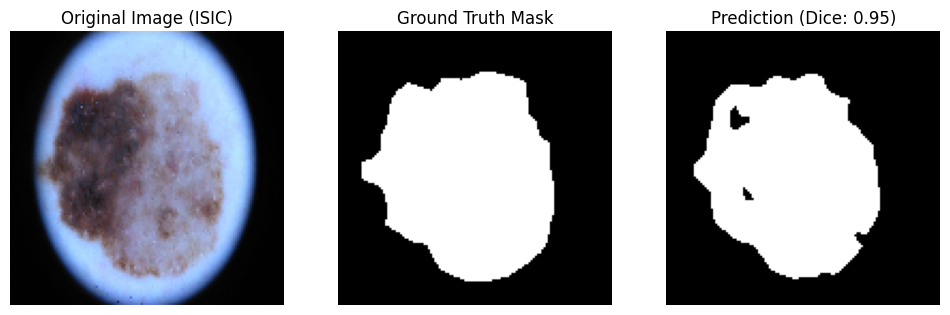

In [27]:
# @title Cell 8: Final Training & Visualization
print("Melatih Model Final dengan Parameter GWO...")

# 1. Train Model Final (Lebih lama: 15 Epoch)
final_model = UNet().to(device)
criterion = DiceLoss()
optimizer = optim.Adam(final_model.parameters(), lr=best_params[0], weight_decay=best_params[1])

train_loader = DataLoader(SkinLesionDataset(train_images, train_masks), batch_size=4, shuffle=True)
val_loader = DataLoader(SkinLesionDataset(val_images, val_masks), batch_size=1, shuffle=False)

for epoch in range(15):
    final_model.train()
    epoch_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = final_model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # Print progress setiap 5 epoch
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/15 - Loss: {epoch_loss/len(train_loader):.4f}")

# 2. Visualisasi pada Data Validasi
final_model.eval()
imgs, masks = next(iter(val_loader)) # Ambil 1 sampel
imgs, masks = imgs.to(device), masks.to(device)

with torch.no_grad():
    pred = final_model(imgs)
    pred_bin = (pred > 0.5).float()

# Plotting
plt.figure(figsize=(12, 5))

# Gambar Asli
plt.subplot(1, 3, 1)
plt.title("Original Image (ISIC)")
plt.imshow(imgs[0].permute(1, 2, 0).cpu())
plt.axis('off')

# Ground Truth (Dokter)
plt.subplot(1, 3, 2)
plt.title("Ground Truth Mask")
plt.imshow(masks[0].cpu().squeeze(), cmap='gray')
plt.axis('off')

# Prediksi AI
plt.subplot(1, 3, 3)
plt.title(f"Prediction (Dice: {dice_coeff(pred_bin, masks):.2f})")
plt.imshow(pred_bin[0].cpu().squeeze(), cmap='gray')
plt.axis('off')

plt.show()

In [30]:
print("\n--- Training Baseline U-Net Model ---")

# 1. Instantiate a new U-Net model
baseline_model = UNet().to(device)

# 2. Define the DiceLoss as the criterion for training
baseline_criterion = DiceLoss()

# 3. Initialize an Adam optimizer with fixed hyperparameters
baseline_lr = 0.001
baseline_weight_decay = 1e-5
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=baseline_lr, weight_decay=baseline_weight_decay)

# 4. Create DataLoader instances
train_loader_baseline = DataLoader(SkinLesionDataset(train_images, train_masks), batch_size=4, shuffle=True)
val_loader_baseline = DataLoader(SkinLesionDataset(val_images, val_masks), batch_size=1, shuffle=False)

num_epochs = 15
print(f"Training with LR={baseline_lr}, Weight Decay={baseline_weight_decay} for {num_epochs} epochs...")

# 5. Implement the training loop for 15 epochs
for epoch in range(num_epochs):
    baseline_model.train() # Set model to training mode
    epoch_loss = 0
    for imgs, masks in train_loader_baseline:
        imgs, masks = imgs.to(device), masks.to(device)

        # Forward pass
        baseline_optimizer.zero_grad()
        outputs = baseline_model(imgs)
        loss = baseline_criterion(outputs, masks)

        # Backward pass and optimize
        loss.backward()
        baseline_optimizer.step()

        epoch_loss += loss.item()

    # d. Print the average loss for the training epoch, every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Training Loss: {epoch_loss/len(train_loader_baseline):.4f}")

print("--- Baseline Model Training Complete ---")

# 6. After training, set the model to evaluation mode
baseline_model.eval()

# 7. Calculate the average Dice score on the validation set
total_dice_score_baseline = 0.0
num_val_images_baseline = 0

with torch.no_grad(): # c. Disable gradient calculation
    for imgs, masks in val_loader_baseline:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = baseline_model(imgs)

        # d. Binarize predictions and calculate Dice coefficient
        preds_bin = (preds > 0.5).float()
        total_dice_score_baseline += dice_coeff(preds_bin, masks)
        num_val_images_baseline += 1

# 8. Calculate the overall average Dice score for the baseline model
average_dice_score_baseline = total_dice_score_baseline / num_val_images_baseline

# 9. Print the calculated average Dice score
print(f"Average Dice Score on validation set for Baseline Model: {average_dice_score_baseline:.4f}")


--- Training Baseline U-Net Model ---
Training with LR=0.001, Weight Decay=1e-05 for 15 epochs...
Epoch 5/15 - Training Loss: 0.4555
Epoch 10/15 - Training Loss: 0.3469
Epoch 15/15 - Training Loss: 0.3171
--- Baseline Model Training Complete ---
Average Dice Score on validation set for Baseline Model: 0.8541


### **Perbandingan Visual pada Satu Gambar**

Visualisasi perbandingan prediksi pada satu sampel validasi...


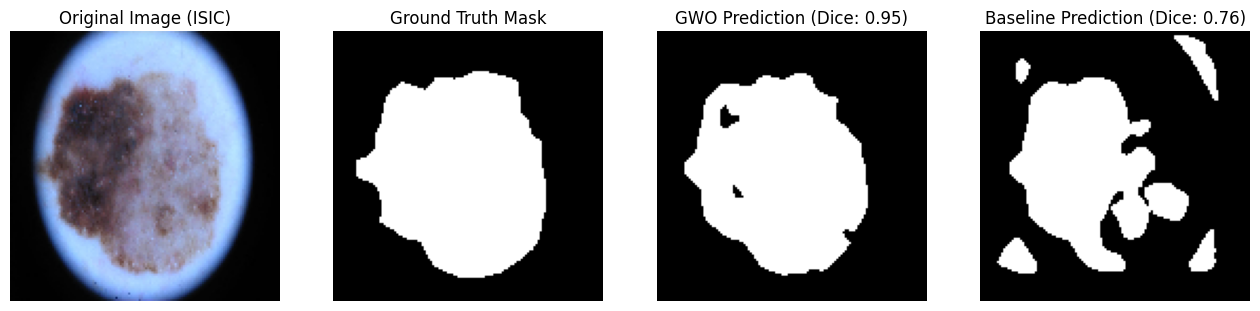

In [32]:
print("Visualisasi perbandingan prediksi pada satu sampel validasi...")

# Ambil satu sampel dari validation loader (pastikan ini konsisten jika diulang)
# Untuk konsistensi, kita bisa ambil gambar pertama dari val_images
sample_idx = 0
img_path_single = val_images[sample_idx]
mask_path_single = val_masks[sample_idx]

single_img_dataset = SkinLesionDataset([img_path_single], [mask_path_single])
single_img_loader = DataLoader(single_img_dataset, batch_size=1, shuffle=False)

imgs_single, masks_single = next(iter(single_img_loader))
imgs_single, masks_single = imgs_single.to(device), masks_single.to(device)

# Prediksi dari model GWO-Optimized (final_model)
final_model.eval()
with torch.no_grad():
    pred_gwo = final_model(imgs_single)
    pred_gwo_bin = (pred_gwo > 0.5).float()
dice_gwo = dice_coeff(pred_gwo_bin, masks_single)

# Prediksi dari model Baseline
baseline_model.eval()
with torch.no_grad():
    pred_baseline = baseline_model(imgs_single)
    pred_baseline_bin = (pred_baseline > 0.5).float()
dice_baseline = dice_coeff(pred_baseline_bin, masks_single)

# Plotting
plt.figure(figsize=(16, 5))

# Gambar Asli
plt.subplot(1, 4, 1)
plt.title("Original Image (ISIC)")
plt.imshow(imgs_single[0].permute(1, 2, 0).cpu())
plt.axis('off')

# Ground Truth Mask
plt.subplot(1, 4, 2)
plt.title("Ground Truth Mask")
plt.imshow(masks_single[0].cpu().squeeze(), cmap='gray')
plt.axis('off')

# Prediksi GWO-Optimized
plt.subplot(1, 4, 3)
plt.title(f"GWO Prediction (Dice: {dice_gwo:.2f})")
plt.imshow(pred_gwo_bin[0].cpu().squeeze(), cmap='gray')
plt.axis('off')

# Prediksi Baseline
plt.subplot(1, 4, 4)
plt.title(f"Baseline Prediction (Dice: {dice_baseline:.2f})")
plt.imshow(pred_baseline_bin[0].cpu().squeeze(), cmap='gray')
plt.axis('off')

plt.show()